## 0. Prerequisites

Loads `topic_model` and `docs` from disk, then applies the custom topic labels produced by `20-llm_labeling.ipynb`.

**Requires** (run prior notebooks first):
- `./BERTopic/` — fitted BERTopic model (`10-topic_modelling.ipynb`)
- `./pickles/first-date_posts-all.pkl` — filtered posts (`00-dataset_preparation.ipynb`)
- `./pickles/topic_metadata_llm.pkl` — LLM-generated topic labels (`20-llm_labeling.ipynb`)

In [6]:
import os
import pandas as pd
from dotenv import load_dotenv
from bertopic import BERTopic

load_dotenv()

# ── Load BERTopic model ───────────────────────────────────────────────────────
# Saved by 10-topic_modelling.ipynb via BERTopic.save("./BERTopic", serialization="safetensors")
topic_model = BERTopic.load("./BERTopic", embedding_model="all-MiniLM-L6-v2")

# ── Reconstruct docs ──────────────────────────────────────────────────────────
# Must match the exact construction used when the model was fitted.
df_posts = pd.read_pickle("./pickles/first-date_posts-all.pkl")
documents = df_posts["title"] + ". " + df_posts["selftext"].fillna("")
documents = documents.apply(lambda x: x.replace("\n", " "))
docs = documents.tolist()

# ── Apply custom labels from 20-llm_labeling.ipynb ───────────────────────────
metadata_df = pd.read_pickle("./pickles/topic_metadata_llm.pkl")
metadata_df["CustomLabel"] = metadata_df["CustomLabel"].str.replace("**", "", regex=False).str.strip()
labels_map = dict(zip(metadata_df["Topic"], metadata_df["CustomLabel"]))
topic_model.set_topic_labels(labels_map)

print(f"✅ Loaded topic model — {len(topic_model.get_topic_info())} topics.")
print(f"✅ Reconstructed {len(docs)} documents.")

✅ Loaded topic model — 33 topics.
✅ Reconstructed 87155 documents.


## 1. Document–Topic Index

Build `docs_sorted` — a flat DataFrame mapping every document to its topic. Used by all downstream cells to retrieve representative posts per topic.

In [7]:
import pandas as pd

# Build a flat document-topic lookup DataFrame.
# Using topic_model.topics_ directly — the Probability column is unavailable
# when the model is loaded from disk (safetensors serialization does not persist it).
docs_sorted = pd.DataFrame({
    'Document': docs,
    'Topic': topic_model.topics_
})

print(f"✅ docs_sorted ready: {len(docs_sorted)} rows, {docs_sorted['Topic'].nunique()} unique topics.")

✅ docs_sorted ready: 87155 rows, 33 unique topics.


## 2. Prompt Template

Defines the sociologist role-play prompt and the `get_script_mining_prompt` helper that injects a topic name and its representative documents into it.

In [8]:
# Prompt to find a controversial scripts:

prompt_1 = """
Role: You are an expert Sociologist specializing in Human Mating Strategies and Digital Intimacy.

The Context:
I am providing you with a list of 10 representative posts from a single topic cluster (Topic Name: "{{TOPIC_NAME}}").
While these posts share a common theme, they likely contain multiple dating scripts.

Definitions:
1.  "Dating Script": A cognitive schema or normative rule consisting of actions, dictating how an interaction should unfold (e.g., "The Man Pays" vs. "Split the Bill").
2.  "Synthetic Anchor": A hypothetical user post that perfectly embodies a specific script using natural, colloquial language (slang, typos, emotional tone).

Your Task:
Analyze the documents and extract the dating scripts. Some documents may contain multiple scripts, or just one single script, or even none. Then, for each script, generate short synthetic training data (anchors) that we will use to find similar posts in a vector database.

Instructions:
1.  Identify Distinct Scripts: Look for mutually exclusive behaviors and try to identify the patterns.
2.  Label & Analyze: Give each script a short formal name and explain its core logic.
3.  Generate Synthetic Anchors (Crucial): For each script, write 3 distinct, hypothetical Reddit posts (2-3 sentences each) that a user following this script would write. Write it in a Reddit style.

Output Format (JSON):
Please provide the response in the following (valid) JSON format:

```json
{
  "topic_context": "Brief summary of the general arena",
  "identified_scripts": [
    {
      "script_name": "Short name of the script (e.g., The Strategic Detachment)",
      "core_logic": "The sociological reason this script exists (e.g., To maintain power via scarcity).",
      "sequence_of_events": "Step 1 -> Step 2 -> Step 3",
      "associated_emotion": "anger/disgust/fear/joy/neutral/sadness/surprise",
      "keywords": ["list", "of", "distinct", "keywords"],
      "synthetic_anchors": [
        "I really like him but I'm gonna wait 3 days to text back so I don't look desperate...",
        "...",
        "..."
      ]
    }
    ...
  ]
}

"""


def get_script_mining_prompt(topic_name, representative_docs):
    # 3. Construct the Prompt
    prompt_result = prompt_1 + f"""
    Topic Name: "{topic_name}"

    The Documents:
    {representative_docs}
    """

    return prompt_result

## 3. Utility Functions

- `format_documents_to_string` — formats a document list into numbered `Document N: …` strings for the prompt
- `extract_json_from_llm_text` — extracts the first valid JSON object from a raw LLM response string
- `json_to_scripts_dataframe` — flattens the `identified_scripts` array from the parsed JSON into a tidy DataFrame

In [12]:
import re
import time
import json
from typing import Dict, Any
from google import genai


def format_documents_to_string(document_list: list) -> str:
    """
    Formats a list of documents into a single string with 'Document N: {doc}' format.

    Args:
        document_list: A list of strings, where each string is a document.

    Returns:
        A single string containing all formatted documents.
    """
    formatted_parts = []

    # Iterate through the list, using enumerate to get the 1-based index (N)
    for index, doc in enumerate(document_list):
        # index is 0-based, so we add 1 for the Document number
        document_number = index + 1

        # Use an f-string to create the formatted line
        formatted_line = f"\n Document {document_number}: {doc}"

        formatted_parts.append(formatted_line)

    # Join all the formatted lines together with a newline character
    return "\n".join(formatted_parts)


def extract_json_from_llm_text(text: str) -> Dict[str, Any]:
    """
    Extracts the first valid JSON object enclosed in triple backticks
    (```json ... ```) or simply the first valid JSON object from a string.

    Args:
        text: The string response from the LLM.

    Returns:
        A dictionary containing the parsed JSON data, or an empty dictionary if
        no valid JSON is found.
    """
    # Regex to find JSON blocks, optionally including Markdown block delimiters (```json ... ```)
    # The pattern looks for the content inside the outermost curly braces { ... }
    # re.DOTALL is crucial to allow the match to span multiple lines

    # Pattern to find content between the first '{' and the last '}'
    match = re.search(r"(\{.*\})", text, re.DOTALL)

    if match:
        json_string = match.group(1)

        # Clean up the string by removing markdown ticks and 'json' tag if present
        json_string = json_string.strip()
        json_string = json_string.replace('```json', '').replace('```', '')

        try:
            # Attempt to parse the cleaned string into a Python dictionary
            json_data = json.loads(json_string)
            return json_data
        except json.JSONDecodeError as e:
            print(f"Error decoding JSON block: {e}")
            # print(f"Problematic JSON string segment: {json_string[:200]}...")
            return {}
    else:
        print("No curly braces found in the LLM response.")
        return {}


def json_to_scripts_dataframe(json_data: dict) -> pd.DataFrame:
    """
    Parses the given JSON structure, extracting the 'identified_scripts'
    array into a DataFrame.

    The 'keywords' list is converted into a comma-separated string for
    easier CSV export/analysis.

    Args:
        json_data: A dictionary loaded from the JSON file.

    Returns:
        A pandas DataFrame containing the details of each identified script.
    """
    # 1. Extract the list of dictionaries under the 'identified_scripts' key
    scripts_list = json_data.get("identified_scripts", [])

    if not scripts_list:
        print("Warning: 'identified_scripts' list is empty or missing.")
        return pd.DataFrame()

    # 2. Process the list data
    processed_scripts = []
    for script in scripts_list:
        # Create a mutable copy of the script dictionary
        processed_script = script.copy()

        # 3. Handle the 'keywords' list: Convert it to a comma-separated string
        keywords = processed_script.get("keywords", [])
        processed_script["keywords"] = ", ".join(keywords)

        # 4. (Optional) Add the main 'topic_context' to each row for reference
        processed_script["topic_context"] = json_data.get("topic_context", "")

        processed_scripts.append(processed_script)

    # 5. Create the DataFrame from the processed list
    df = pd.DataFrame(processed_scripts)

    # 6. Reorder columns for better readability (optional)
    try:
        column_order = [
            "script_name",
            "core_logic",
            "sequence_of_events",
            "associated_emotion",
            "keywords",
            "synthetic_anchors"
        ]
        df = df[column_order]
    except KeyError as e:
        # Handle cases where some keys might be missing in a specific script
        print(f"Warning: Could not reorder columns due to missing key: {e}")
        pass

    return df

## 4. Cost Estimation (Optional)

Iterates all topics, reconstructs the exact prompt that will be sent to the LLM, counts tokens via `tiktoken`, and prints a per-topic and total cost estimate.

Run this before the API call cells to budget the experiment. `PRICE_PER_1M_INPUT_TOKENS` can be adjusted per model.

In [5]:
# Estimate the cost
import tiktoken
import pandas as pd

# Pricing configuration (Example: $2.50 per 1M input tokens for GPT-4o)
PRICE_PER_1M_INPUT_TOKENS = 1.25


def count_tokens(text: str, model: str = "gpt-5") -> int:
    """Returns the number of tokens in a text string."""
    try:
        encoding = tiktoken.encoding_for_model(model)
    except KeyError:
        # Fallback for non-OpenAI models
        encoding = tiktoken.get_encoding("cl100k_base")
    return len(encoding.encode(text))


# Prepare tracking
total_input_tokens = 0
topic_stats = []

print(f"{'Topic ID':<10} | {'Topic Name':<30} | {'Tokens':<10} | {'Est. Price ($)':<15}")
print("-" * 75)

# 1. Iterate through topics to measure tokens
for index, row in topic_model.get_topic_info().iterrows():
    if row['Topic'] == -1:
        continue

    # A. Recreate the prompt logic exactly as your real script does
    representative_docs_list = docs_sorted[docs_sorted['Topic'] == row['Topic']].head(10)['Document'].tolist()
    formatted_docs = format_documents_to_string(representative_docs_list)
    topic_name = row['CustomName']

    prompt = get_script_mining_prompt(topic_name, formatted_docs)

    # B. Count tokens for this specific prompt
    token_count = count_tokens(prompt)
    topic_price = (token_count / 1_000_000) * PRICE_PER_1M_INPUT_TOKENS

    # C. Accumulate and Log
    total_input_tokens += token_count
    topic_stats.append({
        'Topic': row['Topic'],
        'Name': topic_name,
        'Tokens': token_count,
        'Price': topic_price
    })

    print(f"{row['Topic']:<10} | {topic_name[:30]:<30} | {token_count:<10} | ${topic_price:.5f}")

# 2. Final Summary
total_price = (total_input_tokens / 1_000_000) * PRICE_PER_1M_INPUT_TOKENS

print("-" * 75)
print(f"TOTAL INPUT TOKENS: {total_input_tokens}")
print(f"TOTAL ESTIMATED PRICE: ${total_price:.4f}")

Topic ID   | Topic Name                     | Tokens     | Est. Price ($) 
---------------------------------------------------------------------------
0          | First Date Navigation          | 1979       | $0.00247
1          | Post-First Date Follow-Up & Co | 3062       | $0.00383
2          | Modern Dating Frustrations & S | 4757       | $0.00595
3          | Early Dating Texting Etiquette | 3332       | $0.00417
4          | Dating Payment Expectations    | 3386       | $0.00423
5          | Dating Ghosting & Post-Date Di | 4077       | $0.00510
6          | Sudden Ghosting After Initial  | 5876       | $0.00734
7          | Dating & Gift-Giving Etiquette | 1865       | $0.00233
8          | First Date Attire & Anxiety    | 1824       | $0.00228
9          | Early Sexual Expectations in D | 2470       | $0.00309
10         | First/Second Date Kissing Dyna | 1547       | $0.00193
11         | Relationship Betrayal & Post-B | 5993       | $0.00749
12         | Dating with Parental

## OpenAI

In [9]:
import os
import time
import pandas as pd
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()

# ── Configuration ─────────────────────────────────────────────────────────────
OPENAI_API_KEY = os.environ["OPENAI_API_KEY"]
PRICE_PER_1M_INPUT_TOKENS = 1.75
PRICE_PER_1M_OUTPUT_TOKENS = 14.00

client = OpenAI(api_key=OPENAI_API_KEY)

scripts_per_topic = pd.DataFrame()
total_price = 0

for index, row in topic_model.get_topic_info().iterrows():
    start_time = time.time()

    if row['Topic'] == -1:
        continue

    # 1. Prepare Content
    representative_docs = docs_sorted[docs_sorted['Topic'] == row['Topic']].head(10)['Document'].tolist()
    formatted_docs = format_documents_to_string(representative_docs)
    topic_name = row['CustomName']
    prompt = get_script_mining_prompt(topic_name, formatted_docs)

    print(f"\n--- Processing Topic {row['Topic']}: {topic_name} ---")

    # 2. Use the modern Responses API
    try:
        response = client.responses.create(
            model="gpt-5.2",
            input=prompt,
            reasoning={"effort": "medium"}
        )

        # 3. Extract Token Usage
        in_tokens = response.usage.input_tokens
        in_tokens_price = (in_tokens / 1_000_000) * PRICE_PER_1M_INPUT_TOKENS
        out_tokens = response.usage.output_tokens
        out_tokens_price = (out_tokens / 1_000_000) * PRICE_PER_1M_OUTPUT_TOKENS
        total_tokens = in_tokens + out_tokens
        total_price += in_tokens_price + out_tokens_price

        print(
            f"Token Usage -> Input: {in_tokens} ({in_tokens_price:.4f} $) | Output: {out_tokens} ({out_tokens_price:.4f} $) | Total: {total_tokens}")

        llm_response = response.output_text

    except Exception as e:
        print(f"API Error: {e}")
        llm_response = ""

    # 4. Process Results
    json_data = extract_json_from_llm_text(llm_response)

    if json_data:
        scripts_df = json_to_scripts_dataframe(json_data)
        elapsed = time.time() - start_time
        print(f"Status: Success | Time: {elapsed:.2f}s")
    else:
        print("Status: JSON Extraction Failed")
        scripts_df = pd.DataFrame()

    scripts_df['Topic'] = row['Topic']
    scripts_df['CustomName'] = row['CustomName']
    scripts_per_topic = pd.concat([scripts_per_topic, scripts_df], ignore_index=True)

print("\nAll topics processed.")
print(f"\nTotal tokens price: {total_price:.4f} $")


--- Processing Topic 0: First Date Navigation ---
API Error: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-proj-********************************************************************************************************************************************************zdQA. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}


NameError: name 're' is not defined

## Google Gemini

In [13]:
import os
import time
import pandas as pd
from dotenv import load_dotenv
from google import genai
from google.genai import types

load_dotenv()

# ── Configuration ─────────────────────────────────────────────────────────────
GEMINI_API_KEY = os.environ["GEMINI_API_KEY"]

# Use 'gemini-3-pro-preview' for maximum reasoning (thesis quality).
# Use 'gemini-2.5-flash' for faster/cheaper testing.
MODEL_NAME = 'gemini-3-pro-preview'
PRICE_PER_1M_INPUT_TOKENS = 2.00
PRICE_PER_1M_OUTPUT_TOKENS = 12.00

client = genai.Client(api_key=GEMINI_API_KEY)

scripts_per_topic = pd.DataFrame()
total_price = 0

for index, row in topic_model.get_topic_info().iterrows():
    start_time = time.time()

    if row['Topic'] == -1:
        continue

    # A. Prepare Content
    representative_docs = docs_sorted[docs_sorted['Topic'] == row['Topic']].head(10)['Document'].tolist()
    formatted_docs = format_documents_to_string(representative_docs)
    topic_name = row['CustomName']
    prompt = get_script_mining_prompt(topic_name, formatted_docs)

    print(f"\n--- Processing Topic {row['Topic']}: {topic_name} ---")

    # B. Call Gemini API
    try:
        response = client.models.generate_content(
            model=MODEL_NAME,
            contents=prompt,
            config=types.GenerateContentConfig(
                response_mime_type='application/json',
                temperature=0,
            )
        )

        # C. Extract Token Usage
        usage = response.usage_metadata
        in_tokens = usage.prompt_token_count
        out_tokens = usage.candidates_token_count
        in_tokens_price = (in_tokens / 1_000_000) * PRICE_PER_1M_INPUT_TOKENS
        out_tokens_price = (out_tokens / 1_000_000) * PRICE_PER_1M_OUTPUT_TOKENS
        total_tokens = in_tokens + out_tokens
        total_price += in_tokens_price + out_tokens_price

        print(
            f"Token Usage -> Input: {in_tokens} (${in_tokens_price:.4f}) | "
            f"Output: {out_tokens} (${out_tokens_price:.4f}) | "
            f"Total: {total_tokens}"
        )

        llm_response = response.text

    except Exception as e:
        print(f"API Error: {e}")
        llm_response = ""

    # D. Process Results
    json_data = extract_json_from_llm_text(llm_response)

    if json_data:
        scripts_df = json_to_scripts_dataframe(json_data)
        elapsed = time.time() - start_time
        print(f"Status: Success | Time: {elapsed:.2f}s")
    else:
        print("Status: JSON Extraction Failed")
        scripts_df = pd.DataFrame()

    if not scripts_df.empty:
        scripts_df['Topic'] = row['Topic']
        scripts_df['CustomName'] = row['CustomName']
        scripts_per_topic = pd.concat([scripts_per_topic, scripts_df], ignore_index=True)

print("\nAll topics processed.")
print(f"\nTotal tokens price: ${total_price:.4f}")


--- Processing Topic 0: First Date Navigation ---
Token Usage -> Input: 2089 ($0.0042) | Output: 1152 ($0.0138) | Total: 3241
Status: Success | Time: 36.79s

--- Processing Topic 1: Post-First Date Follow-Up & Communication ---
Token Usage -> Input: 2315 ($0.0046) | Output: 1166 ($0.0140) | Total: 3481
Status: Success | Time: 31.01s

--- Processing Topic 2: Modern Dating Frustrations & Self-Perception ---


KeyboardInterrupt: 

### Export & import scripts per topic into csv file

In [15]:
import pandas as pd

os.makedirs("./output_csv", exist_ok=True)

# Iterate through your topics just like before
for index, row in topic_model.get_topic_info().iterrows():
    if row['Topic'] == -1:
        continue

    # Filter the data
    tmp = scripts_per_topic[scripts_per_topic['Topic'] == row['Topic']].copy()

    # OPTIONAL: Enhance readability inside the text
    # If 'sequence_of_events' is a list or comma-separated string, turn it into a vertical list
    # tmp['sequence_of_events'] = tmp['sequence_of_events'].astype(str).str.replace(', ', '\n- ')

    # Define the output filename (changing extension to .xlsx)
    filename = f"./output_csv/scripts_per_topic_{row['Topic']}.xlsx"

    # Create a Pandas Excel writer using XlsxWriter as the engine
    with pd.ExcelWriter(filename, engine='xlsxwriter') as writer:

        # Convert the dataframe to an XlsxWriter Excel object
        tmp.to_excel(writer, sheet_name='Scripts', index=False)

        # Get the workbook and worksheet objects to apply formatting
        workbook = writer.book
        worksheet = writer.sheets['Scripts']

        # 1. Define the 'Wrap Text' format
        # This forces text to break into new lines and expands the row height automatically
        wrap_format = workbook.add_format({
            'text_wrap': True,
            'valign': 'top',  # Align text to the top of the cell
            'align': 'left',
            'border': 1  # Optional: adds a distinct border around cells
        })

        # 2. Apply formatting to specific columns
        # Set columns A through Z (or however many you have) to width 50 and apply wrapping
        # You can adjust '50' to be wider or narrower
        worksheet.set_column('A:Z', 50, wrap_format)

        # If you want specific columns (like 'script_name') to be narrower/wider:
        worksheet.set_column('A:A', 20, wrap_format)  # Script Name narrower
        worksheet.set_column('D:D', 20, wrap_format)  # Associated emotion narrower
        worksheet.set_column('I:I', 20, wrap_format)
        worksheet.set_column('G:G', 5, wrap_format)

        worksheet.set_column('C:C', 60, wrap_format)  # Sequence of events wider

    print(f"Exported formatted Excel: {filename}")

Exported formatted Excel: ./output_csv/scripts_per_topic_0.xlsx
Exported formatted Excel: ./output_csv/scripts_per_topic_1.xlsx
Exported formatted Excel: ./output_csv/scripts_per_topic_2.xlsx
Exported formatted Excel: ./output_csv/scripts_per_topic_3.xlsx
Exported formatted Excel: ./output_csv/scripts_per_topic_4.xlsx
Exported formatted Excel: ./output_csv/scripts_per_topic_5.xlsx
Exported formatted Excel: ./output_csv/scripts_per_topic_6.xlsx
Exported formatted Excel: ./output_csv/scripts_per_topic_7.xlsx
Exported formatted Excel: ./output_csv/scripts_per_topic_8.xlsx
Exported formatted Excel: ./output_csv/scripts_per_topic_9.xlsx
Exported formatted Excel: ./output_csv/scripts_per_topic_10.xlsx
Exported formatted Excel: ./output_csv/scripts_per_topic_11.xlsx
Exported formatted Excel: ./output_csv/scripts_per_topic_12.xlsx
Exported formatted Excel: ./output_csv/scripts_per_topic_13.xlsx
Exported formatted Excel: ./output_csv/scripts_per_topic_14.xlsx
Exported formatted Excel: ./output_

In [ ]:
# Import

import pandas as pd
import glob
import os
import ast


def safe_literal_eval(value):
    """Safely evaluates the string to a Python object (list, dict, etc.)."""
    try:
        # Check if the value is a string before trying to evaluate
        if isinstance(value, str):
            return ast.literal_eval(value)
        return value
    except (ValueError, TypeError, SyntaxError):
        # Return an empty list if evaluation fails (e.g., corrupted string)
        return []


# 1. Define the location and pattern
# Matches the path used in your export: "./output_csv/"
folder_path = "./output_csv/gemini-3-pro/"
# Matches the filename pattern: "scripts_per_topic_*.xlsx"
file_pattern = os.path.join(folder_path, "scripts_per_topic_*.xlsx")

# 2. Find all matching files
all_files = glob.glob(file_pattern)

if not all_files:
    print(f"No files found in {folder_path} matching the pattern!")
else:
    # 3. Read and combine files
    df_list = []

    print(f"Found {len(all_files)} files. Importing...")

    for filename in all_files:
        # Read the specific sheet 'Scripts' that you defined in your export
        try:
            df_temp = pd.read_excel(filename, sheet_name='Scripts')
            df_list.append(df_temp)
        except Exception as e:
            print(f"Error reading {filename}: {e}")

    # 4. Concatenate into a single DataFrame
    # ignore_index=True resets the index to be continuous (0, 1, 2...)
    # rather than keeping the mini-indices from each file.
    restored_scripts_df = pd.concat(df_list, ignore_index=True)

    # Optional: Sort by Topic to restore the original order
    if 'Topic' in restored_scripts_df.columns:
        restored_scripts_df = restored_scripts_df.sort_values('Topic').reset_index(drop=True)

    print("-" * 30)
    print("Import Complete!")
    print(f"Total rows loaded: {len(restored_scripts_df)}")

# Apply the function to the entire 'synthetic_anchors' column
restored_scripts_df['synthetic_anchors'] = (
    restored_scripts_df['synthetic_anchors']
    .apply(safe_literal_eval)
)
scripts_per_topic = restored_scripts_df
scripts_per_topic.columns

## Create evaluation kit

In [ ]:
import pandas as pd
import xlsxwriter
from docx import Document
from docx.shared import Pt, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH

# ==========================================
# CONFIGURATION
# ==========================================
target_topics = [0, 1, 2, 3, 4]  # Change as needed
output_folder = "./output_csv/"

# ==========================================
# GENERATION SCRIPT
# ==========================================

for topic_id in target_topics:
    # --------------------------------------
    # 1. GET DATA
    # --------------------------------------
    # Get representative docs
    # Note: Ensure 'docs_sorted' and 'scripts_per_topic' are available in your environment
    rep_docs = docs_sorted[docs_sorted['Topic'] == topic_id].head(10)['Document'].tolist()

    if not rep_docs:
        print(f"Skipping Topic {topic_id}: No representative docs found.")
        continue

    # Get scripts and label
    topic_scripts = scripts_per_topic[scripts_per_topic['Topic'] == topic_id].copy()
    topic_label = topic_scripts['CustomName'].iloc[0] if not topic_scripts.empty else f"Topic {topic_id}"

    # --------------------------------------
    # 2. GENERATE WORD DOC (Source Material)
    # --------------------------------------
    doc = Document()

    # -- Title --
    title = doc.add_heading(f"TOPIC {topic_id}: {topic_label}", 0)
    title.alignment = WD_ALIGN_PARAGRAPH.CENTER

    # -- Instructions --
    doc.add_heading("STEP 1: Deep Reading", level=1)
    doc.add_paragraph("Please read the 10 representative submissions below to understand the context of this topic.")

    # -- The 10 Posts --
    for i, post_content in enumerate(rep_docs, 1):
        # Post Header
        h = doc.add_heading(f"Submission #{i}", level=2)
        h.style.font.color.rgb = RGBColor(0x2E, 0x74, 0xB5)  # Blue headers

        # Post Body
        p = doc.add_paragraph(str(post_content))
        p.alignment = WD_ALIGN_PARAGRAPH.JUSTIFY

        # Spacer
        doc.add_paragraph("_" * 20)

    # -- Unrevealed Scripts Section (Workspace) --
    doc.add_page_break()
    doc.add_heading("STEP 2: Identify Missed Scripts (False Negatives)", level=1)

    instr2 = doc.add_paragraph(
        "Before looking at the Excel file, did you identify any major normative rules or recurring behaviors "
        "in these texts that you suspect the AI might have missed?"
    )
    instr2.runs[0].bold = True

    doc.add_paragraph("Your Draft Notes (Please copy the final list to Excel later):")
    # Add valid lines for writing
    for _ in range(10):
        doc.add_paragraph("• __________________________________________________________________")

    # Save Word File
    word_filename = f"{output_folder}1_Source_Material_Topic_{topic_id}.docx"
    doc.save(word_filename)

    # --------------------------------------
    # 3. GENERATE EXCEL (Evaluation Task)
    # --------------------------------------
    # Prepare DataFrame: Add 'sequence_of_events'
    cols_to_keep = ['script_name', 'core_logic', 'sequence_of_events', 'synthetic_anchors']
    df_eval = topic_scripts[cols_to_keep].copy()

    # Add placeholder columns for the evaluator
    df_eval['[INPUT] Is present in any submission? (Yes/No)'] = ""
    df_eval['[INPUT] Logic Alignment (High/Partial/Low)'] = ""
    df_eval['[INPUT] Anchors express script? (Yes/No)'] = ""
    df_eval['[INPUT] Type (Classic/Emergent)'] = ""
    df_eval['[INPUT] Comments'] = ""

    # Define Filename
    excel_filename = f"{output_folder}2_Evaluation_Task_Topic_{topic_id}.xlsx"

    with pd.ExcelWriter(excel_filename, engine='xlsxwriter') as writer:
        workbook = writer.book
        ws = workbook.add_worksheet('Evaluation')

        # --- Formats ---
        fmt_wrap = workbook.add_format({'text_wrap': True, 'valign': 'top', 'align': 'left'})
        fmt_header = workbook.add_format({'bold': True, 'bg_color': '#D9E1F2', 'border': 1})
        fmt_input = workbook.add_format({'bg_color': '#FFF2CC', 'border': 1, 'text_wrap': True, 'valign': 'top'})
        fmt_instruction = workbook.add_format({'bold': True, 'font_color': '#C00000', 'font_size': 12})
        fmt_bold = workbook.add_format({'bold': True})

        # --- SECTION A: HEADER & MISSED SCRIPTS ---
        ws.write('A1', f"TOPIC: {topic_label} (ID: {topic_id})", fmt_instruction)

        # False Negative Collection Box
        ws.write('A3', "STEP 3: Missed Scripts (False Negatives)", fmt_bold)
        ws.write('A4', "Please copy the list of MISSED scripts from your Word document here. (One script per line)",
                 fmt_wrap)

        # Create a big yellow box for them to paste the missed scripts
        ws.merge_range('A5:E8', "", fmt_input)
        ws.write_comment('A5', "Parser will count the number of lines in this cell as False Negatives.")

        # --- SECTION B: HOLISTIC CHECK ---
        ws.write('A10', "STEP 4: Holistic Check", fmt_bold)
        ws.write('A11', "Are the scripts below mutually exclusive? (Yes/No)", fmt_header)
        ws.data_validation('B11', {'validate': 'list', 'source': ['Yes', 'No']})
        ws.write('B11', "", fmt_input)

        # --- SECTION C: THE EVALUATION TABLE ---
        ws.write('A13', "STEP 5: Evaluate AI Detected Scripts", fmt_instruction)

        # Write the table headers manually or via pandas
        # We'll use pandas to write the data starting at row 14 (A15 in Excel)
        start_row = 14
        df_eval.to_excel(writer, sheet_name='Evaluation', index=False, startrow=start_row)

        # --- Column Settings ---
        # A: Script Name
        ws.set_column('A:A', 25, fmt_wrap)
        # B: Core Logic
        ws.set_column('B:B', 40, fmt_wrap)
        # C: Sequence (NEW)
        ws.set_column('C:C', 50, fmt_wrap)
        # D: Anchors
        ws.set_column('D:D', 40, fmt_wrap)
        # E-I: Inputs
        ws.set_column('E:I', 25, fmt_input)

        # --- Data Validation (Dropdowns) ---
        # Data starts 1 row after start_row (because of headers)
        first_data_row = start_row + 1
        last_data_row = first_data_row + len(df_eval) - 1

        # Note: Excel columns are 0-indexed in xlsxwriter
        # A=0, B=1, C=2, D=3
        # E=4 (Present), F=5 (Alignment), G=6 (Anchors), H=7 (Type)

        if len(df_eval) > 0:
            # Column E: Is Present?
            ws.data_validation(first_data_row, 4, last_data_row, 4, {'validate': 'list', 'source': ['Yes', 'No']})

            # Column F: Logic Alignment
            ws.data_validation(first_data_row, 5, last_data_row, 5,
                               {'validate': 'list', 'source': ['High', 'Partial', 'Low']})

            # Column G: Anchors Authentic
            ws.data_validation(first_data_row, 6, last_data_row, 6, {'validate': 'list', 'source': ['Yes', 'No']})

            # Column H: Type
            ws.data_validation(first_data_row, 7, last_data_row, 7,
                               {'validate': 'list', 'source': ['Classic', 'Emergent']})

    print(f"Generated Kit for Topic {topic_id}:")
    print(f"  - DOCX: {word_filename}")
    print(f"  - XLSX: {excel_filename}")

### Parse Evaluation Results

Reads back the filled Excel evaluation kits, aggregates TP / FP / FN counts across all topics, and computes precision, recall, F1, anchor validity, and Classic vs. Emergent script ratios.

In [ ]:
import pandas as pd
import glob
import os

# ==========================================
# CONFIGURATION
# ==========================================
# Path where your filled Excel kits are located
input_folder = "./output_csv/gemini-3-pro/Michael-Test/"
file_pattern = "2_Evaluation_Task_Topic_*.xlsx"

# ==========================================
# METRICS INITIALIZATION
# ==========================================
metrics = {
    'TP': 0,
    'FP': 0,
    'FN': 0,
    'High_Alignment': 0,
    'Partial_Alignment': 0,
    'Low_Alignment': 0,
    'Anchor_Yes': 0,
    'Anchor_Total': 0,
    'Classic_Scripts': 0,
    'Emergent_Scripts': 0
}

topic_breakdown = []

# ==========================================
# PROCESSING LOOP
# ==========================================
files = glob.glob(os.path.join(input_folder, file_pattern))

if not files:
    print("No evaluation files found! Check your folder path.")
else:
    print(f"Found {len(files)} files. Starting evaluation...\n")

for filepath in files:
    filename = os.path.basename(filepath)

    # -------------------------------------------------------
    # 1. PARSE FALSE NEGATIVES (FN)
    # -------------------------------------------------------
    # In the new structure, FNs are in the merged cell A5 (Row 4, Col 0).
    # We read the file without a header first to grab this specific cell.
    current_fn = 0
    try:
        # Read the first few rows to grab the text box
        df_header_area = pd.read_excel(filepath, sheet_name='Evaluation', header=None, nrows=10)

        # Access Cell A5 (Row index 4, Column index 0)
        missed_scripts_text = str(df_header_area.iloc[4, 0])

        # Logic: Count non-empty lines
        # "nan" checks handle empty Excel cells read as float NaN
        if missed_scripts_text.lower() == 'nan' or not missed_scripts_text.strip():
            current_fn = 0
        else:
            # Filter out empty lines
            lines = [line for line in missed_scripts_text.split('\n') if line.strip()]
            current_fn = len(lines)

        metrics['FN'] += current_fn

    except Exception as e:
        print(f"Error reading False Negatives from {filename}: {e}")
        current_fn = 0

    # -------------------------------------------------------
    # 2. PARSE THE MAIN EVALUATION TABLE
    # -------------------------------------------------------
    try:
        df_eval = pd.read_excel(filepath, sheet_name='Evaluation', header=14)

        # Filter only rows that have actual script data
        # We check if 'script_name' is not empty
        if 'script_name' in df_eval.columns:
            df_eval = df_eval[df_eval['script_name'].notna()]
        else:
            print(f"Warning: 'script_name' column not found in {filename}")
            continue

        current_tp = 0
        current_fp = 0

        for index, row in df_eval.iterrows():
            # Extract User Inputs safely
            # Note: We access columns by name. Ensure exact spelling matches Excel header.
            is_present = str(row.get('[INPUT] Is present in any submission? (Yes/No)', '')).strip().title()
            alignment = str(row.get('[INPUT] Logic Alignment (High/Partial/Low)', '')).strip().title()
            anchor_valid = str(row.get('[INPUT] Anchors express script? (Yes/No)', '')).strip().title()
            script_type = str(row.get('[INPUT] Type (Classic/Emergent)', '')).strip().title()

            # --- CALCULATE TP / FP ---
            if is_present == 'Yes' and alignment in ['High', 'Partial']:
                metrics['TP'] += 1
                current_tp += 1

                # Metrics only for True Positives
                if alignment == 'High':
                    metrics['High_Alignment'] += 1
                elif alignment == 'Partial':
                    metrics['Partial_Alignment'] += 1
                elif alignment == 'Low':
                    metrics['Low_Alignment'] += 1

                if script_type == 'Classic':
                    metrics['Classic_Scripts'] += 1
                elif script_type == 'Emergent':
                    metrics['Emergent_Scripts'] += 1

            else:
                # False Positive (Present=No OR Alignment=Low)
                metrics['FP'] += 1
                current_fp += 1

            # --- ANCHOR VALIDITY (Evaluated regardless of TP/FP status) ---
            if anchor_valid in ['Yes', 'No']:
                metrics['Anchor_Total'] += 1
                if anchor_valid == 'Yes':
                    metrics['Anchor_Yes'] += 1

    except Exception as e:
        print(f"Error reading Evaluation Table in {filename}: {e}")
        continue

    # Store per-file stats
    topic_breakdown.append({
        'File': filename,
        'TP': current_tp,
        'FP': current_fp,
        'FN': current_fn
    })


# ==========================================
# CALCULATE FINAL METRICS
# ==========================================

def safe_div(n, d):
    return n / d if d > 0 else 0


precision = safe_div(metrics['TP'], (metrics['TP'] + metrics['FP']))
recall = safe_div(metrics['TP'], (metrics['TP'] + metrics['FN']))
f1_score = safe_div(2 * (precision * recall), (precision + recall))

core_logic_high_rate = safe_div(metrics['High_Alignment'], metrics['TP'])
core_logic_partial_rate = safe_div(metrics['Partial_Alignment'], metrics['TP'])
core_logic_high_and_partial_rate = safe_div((metrics['High_Alignment'] + metrics['Partial_Alignment']), metrics['TP'])
core_logic_low_rate = safe_div((metrics['Low_Alignment']), metrics['TP'])
anchor_validity = safe_div(metrics['Anchor_Yes'], metrics['Anchor_Total'])

# ==========================================
# REPORT OUTPUT
# ==========================================
print("-" * 50)
print("FINAL EVALUATION REPORT (Inter-Coder Agreement Metrics)")
print("-" * 50)

print(f"\n--- 1. Efficiency Metrics ---")
print(f"True Positives (TP):  {metrics['TP']}")
print(f"False Positives (FP): {metrics['FP']}")
print(f"False Negatives (FN): {metrics['FN']}")
print(f"\nPRECISION (Trustworthiness):  {precision:.2%}")
print(f"RECALL (Coverage):            {recall:.2%}")
print(f"F1-SCORE (Overall Efficiency):{f1_score:.2%}")

print(f"\n--- 2. Qualitative Metrics ---")
print(f"Core Logic Score (High Alignment):    {core_logic_high_rate:.2%}")
print(f"Core Logic Score (Partial Alignment): {core_logic_partial_rate:.2%}")
print(f"Core Logic Score (High + Partial Alignment): {core_logic_high_and_partial_rate:.2%}")
print(f"Core Logic Score (Low Alignment): {core_logic_low_rate:.2%}")
print(f"Anchor Validity Rate:                 {anchor_validity:.2%}")

print(f"\n--- 3. Theoretical Relevance (on Valid Scripts) ---")
print(f"Classic Scripts:  {metrics['Classic_Scripts']}")
print(f"Emergent Scripts: {metrics['Emergent_Scripts']}")
if (metrics['Classic_Scripts'] + metrics['Emergent_Scripts']) > 0:
    print(f"Ratio (Classic:Emergent): {metrics['Classic_Scripts']}:{metrics['Emergent_Scripts']}")

print("\n--- Per-File Breakdown ---")
if topic_breakdown:
    print(pd.DataFrame(topic_breakdown))

## Visualizations: Analyse the overlapping of the dating-scripts

In [ ]:
import pandas as pd
import glob
import os
import ast
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity


def safe_literal_eval(value):
    try:
        if isinstance(value, str):
            return ast.literal_eval(value)
        return value
    except (ValueError, TypeError, SyntaxError):
        return []


# 1. Define models and paths
models_dict = {
    "Gemini-3-flash": "./output_csv/gemini-3-flash/",
    "Gemini-3-pro": "./output_csv/gemini-3-pro/",
    "GPT-5.2": "./output_csv/gpt-5.2-medium/",
    "GPT-5.1": "./output_csv/gpt-5.1-low/"
}

# 2. Load and consolidate data
all_models_df = []

print("Loading data from all models...")
for model_name, folder_path in models_dict.items():
    file_pattern = os.path.join(folder_path, "scripts_per_topic_*.xlsx")
    all_files = glob.glob(file_pattern)

    if not all_files:
        print(f"  [Warning] No files found for {model_name} in {folder_path}")
        continue

    df_list = []
    for filename in all_files:
        try:
            df_temp = pd.read_excel(filename, sheet_name='Scripts')
            df_list.append(df_temp)
        except Exception as e:
            pass

    if df_list:
        model_df = pd.concat(df_list, ignore_index=True)
        model_df['Model'] = model_name  # Tag the source model
        model_df['synthetic_anchors'] = model_df['synthetic_anchors'].apply(safe_literal_eval)
        all_models_df.append(model_df)

combined_df = pd.concat(all_models_df, ignore_index=True)
print(f"Total scripts loaded: {len(combined_df)}")


# 3. Prepare Text for Embedding
# We combine script name, core logic, and anchors for a rich semantic representation
def prepare_text(row):
    anchors_text = " ".join(row['synthetic_anchors']) if isinstance(row['synthetic_anchors'], list) else str(
        row['synthetic_anchors'])
    return f"{row['script_name']}. {row['core_logic']} {anchors_text}"


combined_df['embedding_text'] = combined_df.apply(prepare_text, axis=1)

# 4. Generate Embeddings (Using your SetFit model for consistency)
print("Generating embeddings using all-MiniLM-L6-v2...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')
embeddings_tmp = embedder.encode(combined_df['embedding_text'].tolist(), show_progress_bar=True)

# Add embeddings back to dataframe for easy filtering
combined_df['embedding'] = list(embeddings_tmp)

# 5. Analysis 1: Intra-Model Overlap (Distinctiveness)
print("\n--- Intra-Model Overlap (Lower is better = More distinct scripts) ---")
model_names = combined_df['Model'].unique()
for model in model_names:
    model_data = combined_df[combined_df['Model'] == model]
    model_embeddings = np.stack(model_data['embedding'].values)

    # Calculate pairwise similarity within the model
    sim_matrix = cosine_similarity(model_embeddings)

    # Get average off-diagonal similarity (excluding self-similarity of 1.0)
    np.fill_diagonal(sim_matrix, np.nan)
    avg_overlap = np.nanmean(sim_matrix)
    print(f"{model}: Average Internal Overlap = {avg_overlap:.4f} (from {len(model_data)} scripts)")

# 6. Analysis 2: Cross-Model Agreement Matrix
print("\n--- Cross-Model Agreement Matrix ---")
# To compare Model A to Model B, we find the average "best match" for each script in Model A against Model B.
matrix_size = len(model_names)
agreement_matrix = np.zeros((matrix_size, matrix_size))

for i, model_a in enumerate(model_names):
    emb_a = np.stack(combined_df[combined_df['Model'] == model_a]['embedding'].values)
    for j, model_b in enumerate(model_names):
        if i == j:
            agreement_matrix[i, j] = 1.0  # Self
            continue

        emb_b = np.stack(combined_df[combined_df['Model'] == model_b]['embedding'].values)

        # Calculate cross-similarity
        cross_sim = cosine_similarity(emb_a, emb_b)

        # For each script in A, find the highest similarity score in B, then average those top scores
        avg_max_sim = np.mean(np.max(cross_sim, axis=1))
        agreement_matrix[i, j] = avg_max_sim

# 7. Visualize the Agreement Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(agreement_matrix, annot=True, cmap="YlGnBu", xticklabels=model_names, yticklabels=model_names, fmt=".3f")
plt.title("Cross-Model Script Agreement (Average Max Cosine Similarity)")
plt.tight_layout()
plt.show()

# (Optional) Export combined data for the next merging step
# combined_df.to_pickle("all_models_embedded.pkl")

## Script Clustering

Agglomerative hierarchical clustering over script embeddings to merge semantically similar sub-scripts across topics into canonical "Master Scripts". The distance threshold controls granularity — lower values produce more clusters.

Loaded 8 scripts from 32 files.
Generating embeddings...


Batches: 100%|██████████| 1/1 [00:00<00:00, 45.08it/s]

Reduced 8 scripts into 2 Master Clusters.


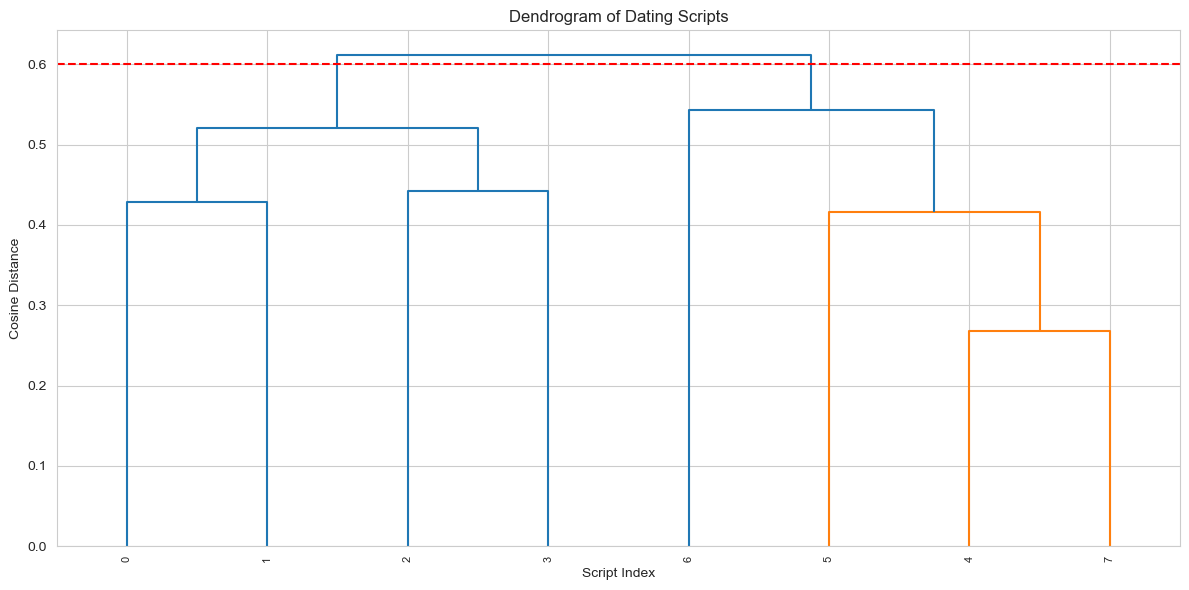


Creating the Master-to-Subscript Dictionary...
✅ Saved 8 sub-script mappings.

Aggregating into Master Clusters...
✅ 2 Master Clusters ready.

--- Cluster 1 preview ---
Name:    The Activity Buffer
Scripts: ['The Low-Stakes Public Meetup', 'The Intimate Boundary Negotiation', 'The Novice Script-Seeking', 'The Traditional Romantic Escalation']
Anchors: 12


In [18]:
import os
import ast
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

# --- 1. Load all scripts from ./output_csv/ ---
folder_path = "./output_csv/"
file_pattern = os.path.join(folder_path, "scripts_per_topic_*.xlsx")
all_files = glob.glob(file_pattern)

if not all_files:
    raise FileNotFoundError(f"No scripts found in {folder_path}. Run the LLM script mining cell first.")


def safe_literal_eval(value):
    try:
        return ast.literal_eval(value) if isinstance(value, str) else value
    except (ValueError, TypeError, SyntaxError):
        return []


df_list = [pd.read_excel(f, sheet_name='Scripts') for f in all_files]
scripts_df = pd.concat(df_list, ignore_index=True)
scripts_df['synthetic_anchors'] = scripts_df['synthetic_anchors'].apply(safe_literal_eval)
print(f"Loaded {len(scripts_df)} scripts from {len(all_files)} files.")

# --- 2. Generate embeddings ---
def prepare_text(row):
    anchors_text = " ".join(row['synthetic_anchors']) if isinstance(row['synthetic_anchors'], list) else str(row['synthetic_anchors'])
    return f"{row['script_name']}. {row['core_logic']} {anchors_text}"

scripts_df['embedding_text'] = scripts_df.apply(prepare_text, axis=1)

print("Generating embeddings...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')
embeddings_arr = embedder.encode(scripts_df['embedding_text'].tolist(), show_progress_bar=True)
scripts_df['embedding'] = list(embeddings_arr)

# --- 3. Calculate the Distance Matrix ---
similarity_matrix = cosine_similarity(embeddings_arr)
distance_matrix = np.clip(1 - similarity_matrix, 0, 1)
np.fill_diagonal(distance_matrix, 0)
condensed_dist = squareform(distance_matrix)

# --- 4. Agglomerative Hierarchical Clustering ---
Z = linkage(condensed_dist, method='average')

distance_threshold = 0.6
scripts_df['Master_Cluster_ID'] = fcluster(Z, t=distance_threshold, criterion='distance')

num_clusters = scripts_df['Master_Cluster_ID'].nunique()
print(f"Reduced {len(scripts_df)} scripts into {num_clusters} Master Clusters.")

# --- 5. Plot the Dendrogram ---
plt.figure(figsize=(12, 6))
plt.title('Dendrogram of Dating Scripts')
plt.xlabel('Script Index')
plt.ylabel('Cosine Distance')
dendrogram(Z, leaf_rotation=90., leaf_font_size=8.)
plt.axhline(y=distance_threshold, color='r', linestyle='--')
plt.tight_layout()
plt.show()

# --- 6. MANUAL NAMING STEP ---
# Update this mapping after inspecting the dendrogram and cluster contents below.
cluster_name_mapping = {
    1: "The Activity Buffer",
    2: "The Investment Calibration Protocol",
    3: "The Structural Gatekeeping (Pay-for-Intent)",
    4: "The Red Flag Mitigation Strategy",
    5: "The Progressive Disclosure Protocol",
    6: "The Pre-emptive Credential Check",
    7: "The Algorithmic Trojan Horse",
    8: "The Impression Management Calibration",
    9: "The Sexual False Start",
    10: "The Chemistry Litmus Test",
    11: "The Performative Reach",
    12: "The Consumption Signal"
}

scripts_df['master_cluster_name'] = scripts_df['Master_Cluster_ID'].map(
    lambda x: cluster_name_mapping.get(x, f"Unnamed Cluster {x}")
)

# --- 7. Save lookup dictionary ---
print("\nCreating the Master-to-Subscript Dictionary...")

lookup_columns = [
    'Master_Cluster_ID', 'master_cluster_name', 'script_name',
    'core_logic', 'sequence_of_events', 'associated_emotion', 'keywords', 'Topic', 'CustomName'
]
df_script_dictionary = scripts_df[[c for c in lookup_columns if c in scripts_df.columns]].copy()
df_script_dictionary.rename(columns={'script_name': 'sub_script_name'}, inplace=True)

os.makedirs("./pickles", exist_ok=True)
df_script_dictionary.to_pickle("./pickles/master_to_subscript_dictionary.pkl")
print(f"✅ Saved {len(df_script_dictionary)} sub-script mappings.")

# --- 8. Aggregate into Master Clusters ---
print("\nAggregating into Master Clusters...")

master_clusters_df = scripts_df.groupby('Master_Cluster_ID').agg({
    'master_cluster_name': 'first',
    'script_name': lambda x: list(x),
    'core_logic': lambda x: " | ".join(x),
    'synthetic_anchors': 'sum'
}).reset_index()[['Master_Cluster_ID', 'master_cluster_name', 'script_name', 'core_logic', 'synthetic_anchors']]

print(f"✅ {len(master_clusters_df)} Master Clusters ready.")
print(f"\n--- Cluster 1 preview ---")
print(f"Name:    {master_clusters_df.iloc[0]['master_cluster_name']}")
print(f"Scripts: {master_clusters_df.iloc[0]['script_name']}")
print(f"Anchors: {len(master_clusters_df.iloc[0]['synthetic_anchors'])}")

### Create human-readable labels new master clusters

In [19]:
import os
import re
import time
import pandas as pd
from dotenv import load_dotenv
from ollama import chat, ChatResponse, Client
from google import genai
from google.genai import types

load_dotenv()

# ── Configuration ─────────────────────────────────────────────────────────────
OLLAMA_API_KEY = os.environ["OLLAMA_API_KEY"]
GEMINI_API_KEY = os.environ["GEMINI_API_KEY"]

MODEL_NAME = 'gemini-3-flash-preview'
local_requests = False

gemini_client = genai.Client(api_key=GEMINI_API_KEY)


def get_new_script_labels(row, max_anchors=19):
    if isinstance(row['script_name'], list):
        script_names = ", ".join(row['script_name'])
    else:
        script_names = str(row['script_name'])

    core_logics = str(row['core_logic'])[:10000]

    if isinstance(row['synthetic_anchors'], list):
        anchors_to_use = row['synthetic_anchors'][:max_anchors]
        synthetic_anchors = "\n- ".join(anchors_to_use)
    else:
        synthetic_anchors = str(row['synthetic_anchors'])

    prompt = f"""
    You are a dating culture and dating scripts specialist.

    Your task:
    You will receive: 1) dating script names, 2) core logic of a scripts, and 3) synthetic anchors.
    All of them belong to a newly created dating script which results out of the aggregation of multiple small sub-scripts with given characteristics.
    Synthetic anchors represent a golden standard submissions, which express signs of a particular dating script, potentially written by a Reddit user.
    Based on that information, give me a suitable name of the this master cluster/dating script.

    --INPUT BEGIN--
    Dating script names: [{script_names}]
    Core logics: [{core_logics}]
    Synthetic anchors: [{synthetic_anchors}]
    --INPUT END--

    Provide output exactly in this format:
    Dating script label: {{label}}
    """

    if local_requests:
        response: ChatResponse = chat(model='gemma3', messages=[{'role': 'user', 'content': prompt}])
        llm_response = response['message']['content']
    else:
        ollama_client = Client(
            host="https://ollama.com",
            headers={'Authorization': f'Bearer {OLLAMA_API_KEY}'}
        )
        llm_response = ""
        for part in ollama_client.chat('gemma3:27b', messages=[{'role': 'user', 'content': prompt}], stream=True):
            chunk = part.get('message', {}).get('content')
            if chunk:
                llm_response += chunk

    pattern = r"Dating script label:\s*(?P<label>.*)"
    match = re.search(pattern, llm_response, re.IGNORECASE)

    topic_label = ""
    if match:
        topic_label = match.group('label').strip().replace('**', '').replace('"', '')

    return {"label": topic_label}


cluster_metadata_list = []
print("--- Starting Master Cluster Renaming ---")

for index, row in master_clusters_df.iterrows():
    cluster_id = row['Master_Cluster_ID']

    new_label_info = get_new_script_labels(row)
    new_label = new_label_info["label"]

    if not new_label:
        new_label = f"Master Cluster {cluster_id}"

    print(f"Cluster {cluster_id}: {new_label}")

    cluster_metadata_list.append({
        'Master_Cluster_ID': cluster_id,
        'master_cluster_name': new_label,
        'original_script_names': row['script_name'],
        'core_logic': row['core_logic'],
        'synthetic_anchors': row['synthetic_anchors']
    })

# --- EXPORT ---
new_master_clusters_df = pd.DataFrame(cluster_metadata_list)
output_path = './pickles/master_clusters_labeled.pkl'
new_master_clusters_df.to_pickle(output_path)
print(f"\n✅ Master clusters with new labels saved to: {output_path}")

--- Starting Master Cluster Renaming ---
Cluster 1: The Anxious & Calculated First Date
Cluster 2: Calculated Ambivalence

✅ Master clusters with new labels saved to: ./pickles/master_clusters_labeled.pkl


In [20]:
import pandas as pd

input_path = './pickles/master_clusters_labeled.pkl'
master_clusters_df = pd.read_pickle(input_path)
master_clusters_df

,Master_Cluster_ID,master_cluster_name,original_script_names,core_logic,synthetic_anchors
0,1,The Anxious & Calculated First Date,"[The Low-Stakes Public Meetup, The Intimate Bo...","To minimize physical risk, financial investmen...",[I always do coffee for a first date from Hing...
1,2,Calculated Ambivalence,"[Strategic Detachment (Playing it Cool), Texti...",Deliberately restricting communication between...,"[We set up our second date for Friday, so I'm ..."
